**Aluno:** Otávio Augusto Reis Nascimento<br>
**Projeto:** Superstore, analisando dados.

In [ ]:
!pip install plotly --quiet

# Bibliotecas para manipulação de dados

In [ ]:
import pandas as pd
import numpy as np

# Bibliotecas para visualização

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configurações visuais

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12


#Carregamento dos Dados
Realizado o upload do arquivo e carregamento do dataset em um DataFrame do pandas.

In [ ]:
from google.colab import files

arquivo = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


#Exploração Inicial
Examinando a estrutura do dataset: <br>
-tipos de dados,<br>
-primeiras linhas, <br>
-estatísticas descritivas<br>
-verificação de valores ausentes.

# Visualização das primeiras linhas

In [ ]:
print("=" * 60)
print("PRIMEIRAS 5 LINHAS DO DATASET")
print("=" * 60)

# Obtém o nome do arquivo dos arquivos carregados
nome_arquivo = next(iter(arquivo))

# Lê o arquivo CSV em um DataFrame do pandas, especificando a codificação latin1
df = pd.read_csv(nome_arquivo, encoding='latin1')

display(df.head())

PRIMEIRAS 5 LINHAS DO DATASET


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#Informações gerais sobre o dataset

In [ ]:
print("\n" + "=" * 60)
print("INFORMAÇÕES GERAIS (TIPOS E NULOS)")
print("=" * 60)
df.info()


INFORMAÇÕES GERAIS (TIPOS E NULOS)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9

#Estatísticas descritivas

In [ ]:
print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
display(df.describe())


ESTATÍSTICAS DESCRITIVAS


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


#Verificação de valores nulos

In [ ]:
print("\n" + "=" * 60)
print("VALORES NULOS POR COLUNA")
print("=" * 60)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
tabela_nulos = pd.DataFrame({'Quantidade': nulos, 'Percentual (%)': nulos_pct})
display(tabela_nulos[tabela_nulos['Quantidade'] > 0])



VALORES NULOS POR COLUNA


,Quantidade,Percentual (%)


#Verificação de duplicatas

In [ ]:
print("\n" + "=" * 60)
print("VERIFICAÇÃO DE DUPLICATAS")
print("=" * 60)
duplicatas = df.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicatas}")


VERIFICAÇÃO DE DUPLICATAS
Total de linhas duplicadas: 0


#Tratamento e Preparação dos Dados

Realizando a limpeza do dataset: remoção de duplicatas, tratamento de nulos,
conversão de tipos de dados e padronização de colunas. No dataset fornecido não foi encontrado valores nulos e duplicatas. Estou prosseguindo com o código ensinado em aula para realização do exercício.

#Remoção Duplicatas

In [ ]:
df = df.drop_duplicates()
print(f"Duplicatas removidas. Linhas restantes: {len(df)}")

Duplicatas removidas. Linhas restantes: 9994


#Padronização dos nomes das colunas

Remove espaços, acentos e coloca em minúsculo com underline

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
print(f"\n Colunas padronizadas: {list(df.columns)}")



 Colunas padronizadas: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


#Conversão de datas

In [ ]:
colunas_data = ['order_date', 'ship_date']
for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
        print(f"Coluna '{col}' convertida para data")

Coluna 'order_date' convertida para data
Coluna 'ship_date' convertida para data


#Conversão de Colunas numéricas

In [ ]:
colunas_numericas = ['sales', 'profit', 'discount', 'quantity']
for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\n Colunas numéricas convertidas com sucesso!")


 Colunas numéricas convertidas com sucesso!


#Tratamento de valores nulos restantes

In [ ]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    elif df[col].dtype == 'object':
        df[col] = df[col].fillna('Desconhecido')

print(" Valores nulos tratados!")
print(f"\n Dataset após tratamento: {df.shape[0]} linhas × {df.shape[1]} colunas")

 Valores nulos tratados!

 Dataset após tratamento: 9994 linhas × 21 colunas


#Tratamento de Outliers

Identificação e Tratamento de Outliers
Foi utilizado o método IQR (Intervalo Interquartil) para detectar e tratar outliers
nas variáveis numéricas principais.

#Identificação de outliers com método IQR

In [ ]:
def identificar_outliers_iqr(dataframe, coluna):
    Q1 = dataframe[coluna].quantile(0.25)
    Q3 = dataframe[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[coluna] < limite_inferior) | (dataframe[coluna] > limite_superior)]
    return limite_inferior, limite_superior, len(outliers)

In [ ]:
coluna_vendas = 'sales'
limite_inferior_vendas, limite_superior_vendas, num_outliers_vendas = identificar_outliers_iqr(df, coluna_vendas)

print(f"Resultados para a coluna '{coluna_vendas}':")
print(f"  Limite Inferior: {limite_inferior_vendas:.2f}")
print(f"  Limite Superior: {limite_superior_vendas:.2f}")
print(f"  Número de Outliers encontrados: {num_outliers_vendas}")

Resultados para a coluna 'sales':
  Limite Inferior: -271.71
  Limite Superior: 498.93
  Número de Outliers encontrados: 1167


#Verificação nas colunas principais

In [ ]:
colunas_verificar = ['sales', 'profit', 'discount']
print("=" * 60)
print("DETECÇÃO DE OUTLIERS (MÉTODO IQR)")
print("=" * 60)

for col in colunas_verificar:
    if col in df.columns:
        inf, sup, qtd = identificar_outliers_iqr(df, col)
        print(f"\n {col.upper()}")
        print(f"   Limite inferior: {inf:.2f} | Limite superior: {sup:.2f}")
        print(f"   Outliers encontrados: {qtd} registros")

DETECÇÃO DE OUTLIERS (MÉTODO IQR)

 SALES
   Limite inferior: -271.71 | Limite superior: 498.93
   Outliers encontrados: 1167 registros

 PROFIT
   Limite inferior: -39.72 | Limite superior: 70.82
   Outliers encontrados: 1881 registros

 DISCOUNT
   Limite inferior: -0.30 | Limite superior: 0.50
   Outliers encontrados: 856 registros


#Visualização de outliers com boxplot

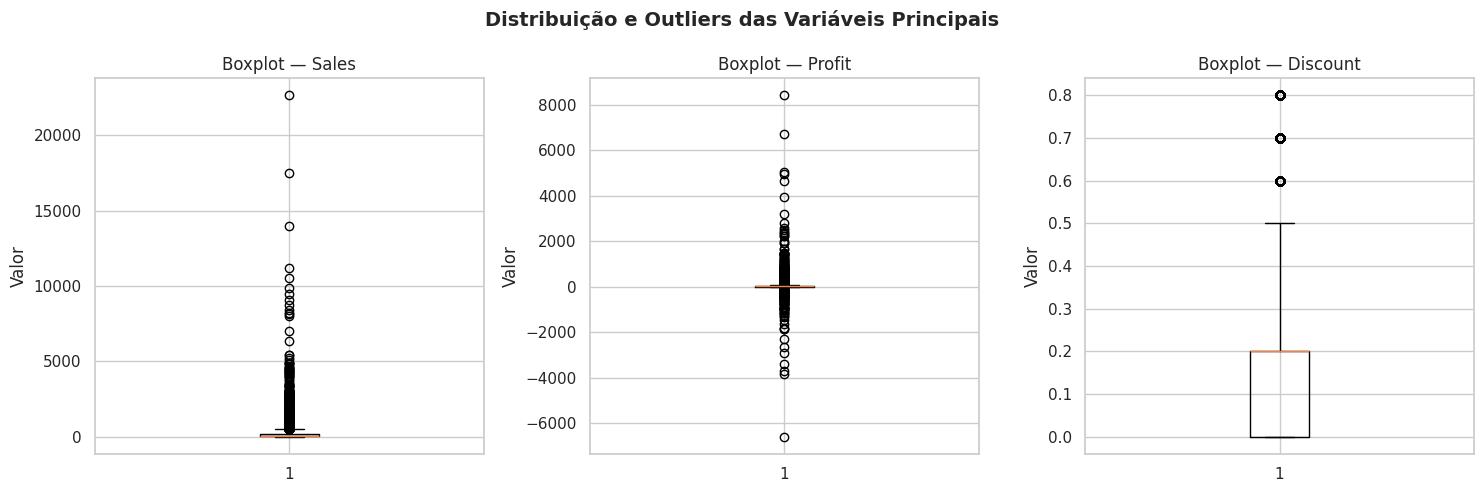

In [ ]:
fig, axes = plt.subplots(1, len(colunas_verificar), figsize=(15, 5))
for i, col in enumerate(colunas_verificar):
    if col in df.columns:
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f'Boxplot — {col.capitalize()}')
        axes[i].set_ylabel('Valor')

plt.suptitle('Distribuição e Outliers das Variáveis Principais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Análise dos Outliers:

**Venda**: Foram registrados 1.167 casos de
vendas que se desviaram significativamente do padrão, indicando transações de valor excepcionalmente alto ou, em menor proporção, muito baixo. Estes casos requerem investigação para compreender a origem dessas anomalias e seu impacto no faturamento.<br><br>
**Lucro**: Observamos 1.881 ocorrências de lucros atípicos. Este número elevado sugere a presença tanto de transações com perdas substanciais quanto de operações com rentabilidade muito acima da média. Uma análise detalhada é fundamental para identificar fatores de risco e de sucesso.
<br><br>
**Desconto**: Identificamos 856 registros de descontos que fogem ao comportamento usual. Isso pode apontar para o uso excessivo de descontos em algumas situações ou para promoções específicas que distorcem a margem, demandando uma revisão das políticas comerciais.






#Análise Exploratória dos Dados (EDA)

#Análise de Vendas e Lucro por Categoria

In [ ]:
vendas_categoria = df.groupby('category').agg(
    total_vendas=('sales', 'sum'),
    total_lucro=('profit', 'sum'),
    qtd_pedidos=('sales', 'count')
).reset_index().sort_values('total_vendas', ascending=False)

print("=" * 60)
print("VENDAS E LUCRO POR CATEGORIA")
print("=" * 60)
display(vendas_categoria)

VENDAS E LUCRO POR CATEGORIA


,category,total_vendas,total_lucro,qtd_pedidos
2,Technology,836154.0330,145454.9481,1847
0,Furniture,741999.7953,18451.2728,2121
1,Office Supplies,719047.0320,122490.8008,6026


# Gráfico de barras duplas

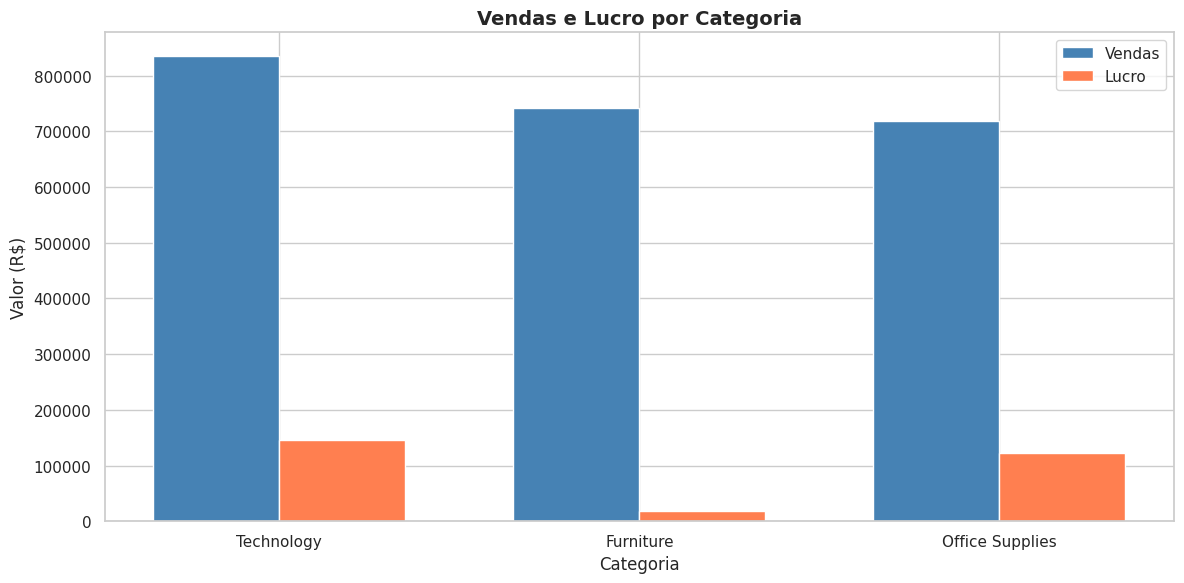

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(vendas_categoria))
largura = 0.35

barras_vendas = ax.bar([i - largura/2 for i in x], vendas_categoria['total_vendas'],
                        largura, label='Vendas', color='steelblue')
barras_lucro = ax.bar([i + largura/2 for i in x], vendas_categoria['total_lucro'],
                       largura, label='Lucro', color='coral')

ax.set_title('Vendas e Lucro por Categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Valor (R$)')
ax.set_xticks(x)
ax.set_xticklabels(vendas_categoria['category'])
ax.legend()
plt.tight_layout()
plt.show()

#Análise do gráfico de barras duplas

**Tecnologia:** Principal motor de vendas e lucro, demonstrando alta performance.<br><br>
**Mobiliário:** Segundo maior em vendas, mas com lucro proporcionalmente o pior, indicando urgência na revisão de custos/precificação.<br><br>
**Material de Escritório:** Vendas ligeiramente menores que Mobiliário, porém com lucro significativamente maior, ressaltando sua eficiência e valor estratégico.

# Desempenho por Segmento de Cliente

In [ ]:
vendas_segmento = df.groupby('segment').agg(
    total_vendas=('sales', 'sum'),
    total_lucro=('profit', 'sum'),
    margem_media=('profit', 'mean')
).reset_index()

print("=" * 60)
print("DESEMPENHO POR SEGMENTO DE CLIENTE")
print("=" * 60)
display(vendas_segmento)

DESEMPENHO POR SEGMENTO DE CLIENTE


,segment,total_vendas,total_lucro,margem_media
0,Consumer,1.161401e+06,134119.2092,25.836873
1,Corporate,7.061464e+05,91979.1340,30.456667
2,Home Office,4.296531e+05,60298.6785,33.818664


# Gráfico de pizza — participação nas vendas

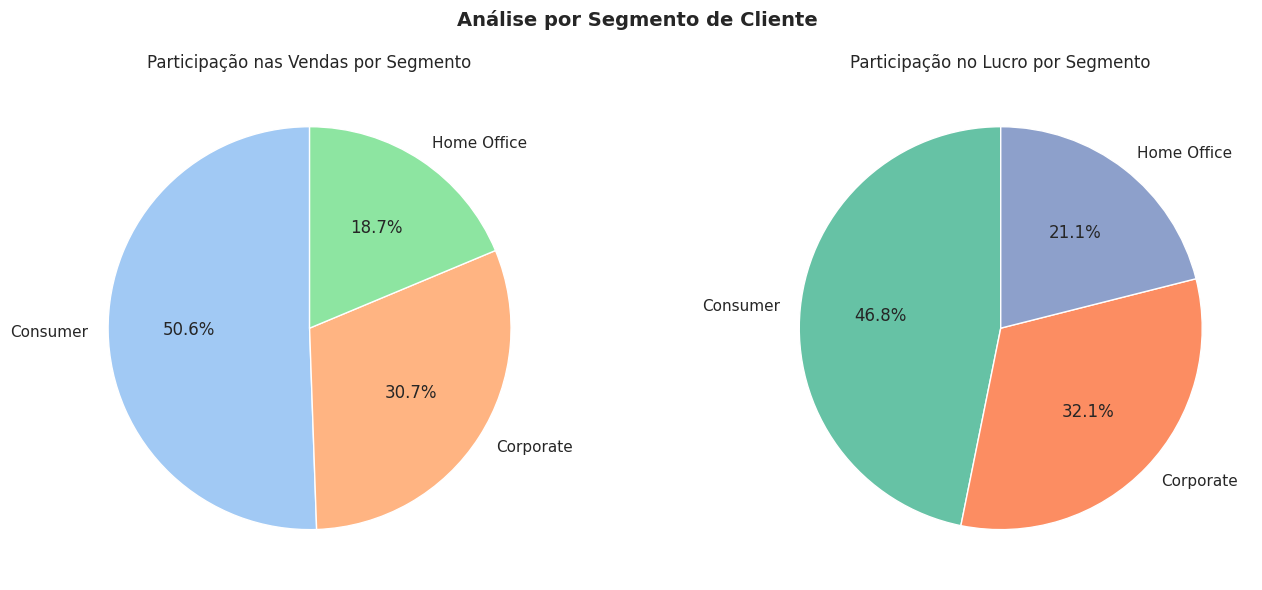

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(vendas_segmento['total_vendas'], labels=vendas_segmento['segment'],
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[0].set_title('Participação nas Vendas por Segmento')

axes[1].pie(vendas_segmento['total_lucro'], labels=vendas_segmento['segment'],
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
axes[1].set_title('Participação no Lucro por Segmento')

plt.suptitle('Análise por Segmento de Cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Análise gráfico de Pizza

**Consumidor**: É o maior em vendas e lucro total, mas tem a menor margem média (25.84%), indicando alto volume com menor rentabilidade por unidade.<br><br>
**Corporativo**: Segundo em vendas e lucro, com margem média (30.46%) superior ao Consumidor, mostrando maior rentabilidade por transação.<br><br>
**Home Office**: Menor em vendas e lucro total, mas o de maior margem média (33.82%), destacando-se como o mais rentável por transação, com potencial para expansão.

 # Impacto dos Descontos na Rentabilidade

#Relação entre desconto e lucro

In [ ]:
print("=" * 60)
print("IMPACTO DO DESCONTO NO LUCRO")
print("=" * 60)

# Faixas de desconto para análise
df['faixa_desconto'] = pd.cut(df['discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['Sem desconto', '1–10%', '11–20%', '21–30%', '31–50%', '> 50%'])

desconto_lucro = df.groupby('faixa_desconto', observed=False).agg(
    lucro_medio=('profit', 'mean'),
    total_vendas=('sales', 'sum'),
    qtd=('profit', 'count')
).reset_index()

display(desconto_lucro)

IMPACTO DO DESCONTO NO LUCRO


,faixa_desconto,lucro_medio,total_vendas,qtd
0,Sem desconto,66.900292,1.087908e+06,4798
1,1–10%,96.055074,5.436935e+04,94
2,11–20%,24.738824,7.921529e+05,3709
3,21–30%,-45.679636,1.032267e+05,227
4,31–50%,-156.282991,1.953148e+05,310
5,> 50%,-89.438144,6.422874e+04,856


# Gráfico de dispersão — **Desconto** vs **Lucro**

In [ ]:
fig = px.scatter(df, x='discount', y='profit',
                 color='category' if 'category' in df.columns else None,
                 opacity=0.5,
                 title='Relação entre Desconto e Lucro por Transação',
                 labels={'discount': 'Desconto (%)', 'profit': 'Lucro (R$)'})
fig.update_layout(template='plotly_white')
fig.show()

#Análise do gráfico de dispersão

**Lucro positivo:** Transações sem desconto e com descontos baixos (1-10%) geram o maior lucro médio.<br><br>
**Lucro positivo**, mas menor: Descontos moderados (11-20%) ainda são lucrativos, mas com margens reduzidas.<br><br>
**Prejuízo**: Descontos elevados (21% ou mais) resultam em lucro médio negativo, causando perdas financeiras.<br><br>
**Conclusão**: É urgente reavaliar a política de descontos acima de 20%, pois eles estão comprometendo severamente a rentabilidade da empresa, mesmo que aumentem o volume de vendas. O Gráfico de barras abaixo irá demonstrar a análise.

# Gráfico de barras — lucro médio por faixa de desconto

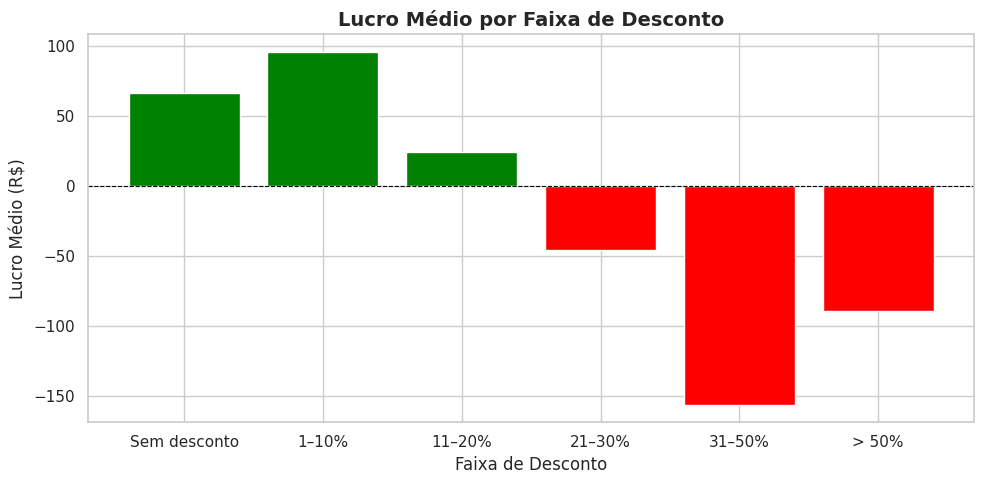

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 5))
cores = ['green' if v >= 0 else 'red' for v in desconto_lucro['lucro_medio']]
ax2.bar(desconto_lucro['faixa_desconto'], desconto_lucro['lucro_medio'], color=cores)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Lucro Médio por Faixa de Desconto', fontsize=14, fontweight='bold')
ax2.set_xlabel('Faixa de Desconto')
ax2.set_ylabel('Lucro Médio (R$)')
plt.tight_layout()
plt.show()

#Tendências ao Longo do Tempo

#Análise de tendência temporal

In [ ]:
df['ano'] = df['order_date'].dt.year
df['mes'] = df['order_date'].dt.month
df['ano_mes'] = df['order_date'].dt.to_period('M').astype(str)

tendencia_mensal = df.groupby('ano_mes').agg(
    total_vendas=('sales', 'sum'),
    total_lucro=('profit', 'sum')
).reset_index()

print("=" * 60)
print("TENDÊNCIA MENSAL DE VENDAS E LUCRO")
print("=" * 60)

fig = go.Figure()
fig.add_trace(go.Scatter(x=tendencia_mensal['ano_mes'], y=tendencia_mensal['total_vendas'],
                          mode='lines+markers', name='Vendas', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=tendencia_mensal['ano_mes'], y=tendencia_mensal['total_lucro'],
                          mode='lines+markers', name='Lucro', line=dict(color='coral')))

fig.update_layout(
    title='Evolução Mensal de Vendas e Lucro',
    xaxis_title='Período',
    yaxis_title='Valor (R$)',
    template='plotly_white',
    xaxis=dict(tickangle=45)
)
fig.show()

# Vendas por ano
vendas_ano = df.groupby('ano')['sales'].sum().reset_index()
print("\n Vendas totais por ano:")
display(vendas_ano)

TENDÊNCIA MENSAL DE VENDAS E LUCRO



 Vendas totais por ano:


,ano,sales
0,2014.0,178906.6897
1,2015.0,164213.4847
2,2016.0,271489.8529
3,2017.0,273307.2843


#Correlação entre variáveis numéricas

MAPA DE CORRELAÇÃO ENTRE VARIÁVEIS


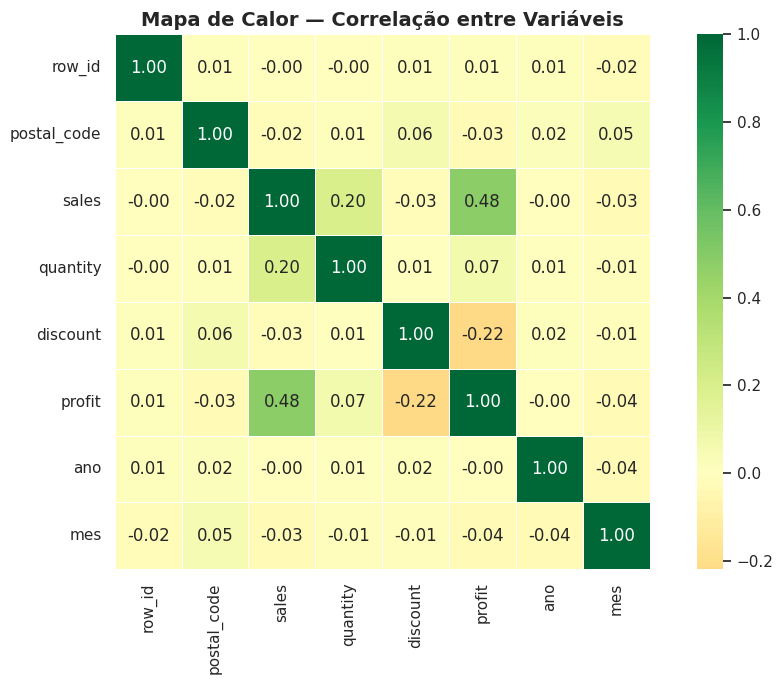

In [ ]:
print("=" * 60)
print("MAPA DE CORRELAÇÃO ENTRE VARIÁVEIS")
print("=" * 60)

colunas_numericas_df = df.select_dtypes(include=['float64', 'int64'])
correlacao = colunas_numericas_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Mapa de Calor — Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Analisando a evolução **Mensal** e **Lucro** junto com o **Mapa de Calor**

**Tendências ao Longo do Tempo** (Gráfico de Evolução Mensal de Vendas e Lucro):<br>
 O gráfico mostra um crescimento geral tanto nas vendas quanto no lucro ao longo dos anos, com forte sazonalidade, indicando picos e vales em determinados meses. As vendas anuais confirmam essa ascensão contínua.<br><br>

**Mapa de Calor (Correlação entre Variáveis):**<br>
 O mapa de calor revela que Vendas e Lucro têm uma correlação positiva moderada (0.48), ou seja, geralmente quando as vendas aumentam, o lucro também tende a aumentar. Há uma correlação negativa entre Desconto e Lucro (-0.22), confirmando que descontos mais altos tendem a reduzir o lucro. A Quantidade vendida também tem uma correlação positiva com Vendas (0.20) e Lucro (0.07), mas em menor grau.

#KPIs e Resumo Executivo

In [ ]:
print("=" * 60)
print("PRINCIPAIS INDICADORES DE DESEMPENHO (KPIs)")
print("=" * 60)

total_vendas      = df['sales'].sum()
total_lucro       = df['profit'].sum()
margem_lucro      = (total_lucro / total_vendas * 100)
ticket_medio      = df['sales'].mean()
total_pedidos     = len(df)
desconto_medio    = df['discount'].mean() * 100

print(f"Total de Vendas:         R$ {total_vendas:,.2f}")
print(f"Total de Lucro:          R$ {total_lucro:,.2f}")
print(f"Margem de Lucro:         {margem_lucro:.2f}%")
print(f"Ticket Médio por Pedido: R$ {ticket_medio:,.2f}")
print(f"Total de Pedidos:        {total_pedidos:,}")
print(f"Desconto Médio:          {desconto_medio:.2f}%")

PRINCIPAIS INDICADORES DE DESEMPENHO (KPIs)
Total de Vendas:         R$ 2,297,200.86
Total de Lucro:          R$ 286,397.02
Margem de Lucro:         12.47%
Ticket Médio por Pedido: R$ 229.86
Total de Pedidos:        9,994
Desconto Médio:          15.62%


In [ ]:
print("\n" + "=" * 60)
print("PRIMEIRAS 5 LINHAS DA COLUNA 'order_date'")
print("=" * 60)
display(df['order_date'].head())


PRIMEIRAS 5 LINHAS DA COLUNA 'order_date'


,order_date
0,2016-08-11
1,2016-08-11
2,2016-12-06
3,2015-11-10
4,2015-11-10


#Resumo Executivo:

Com base na análise, as principais recomendações e pontos de atenção são:
<br>
**-Reavaliar Descontos**: Reduzir ou eliminar descontos acima de 20%, pois geram prejuízo. Pequenos descontos (1-10%) são os mais lucrativos.<br>
**-Otimizar Mobiliário**: Investigar a baixa rentabilidade da categoria 'Mobiliário' (muita venda, pouco lucro).<br>
**-Expandir Home Office**: Explorar o potencial do segmento 'Home Office', que é o mais rentável por transação.<br>
**-Analisar Outliers**: Entender as causas das transações de vendas e lucros atípicos.<br>
**-Planejamento Sazonal**: Considerar a forte sazonalidade para planejar estoque e promoções.

**Salvando arquivo** - Faz Download da nova lista com as correções para utilização no Looker Studio - Data Studio



In [ ]:
# Exportação do arquivo
df.to_csv('dados_tratados.csv', index=False, encoding='utf-8-sig')
files.download('dados_tratados.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>